# Exercício:

## 01 – Do exercício 2 da aula 15, exporte o objeto DataFrame contendo as frequências absolutas de cada aminoácido em cada proteína para .csv, instancie um objeto da classe DataFrame. Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas de tendência central. Qual o valor de média, mediana e moda da Serina nos genes analisados? E do terceiro gene?

In [4]:
import pandas as pd

In [8]:
aminoacidos = pd.read_csv('genes_aa.csv', index_col= 0)
aminoacidos

,BCRA1,TP53,HLA-A,SOD2,APOE
Metionina,30,12,8,3,9
Aspartato,85,20,24,8,13
Leucina,156,32,29,24,41
Serina,224,38,24,10,18
Alanina,84,24,36,19,40
Arginina,76,26,28,7,36
Valina,101,18,22,11,24
Glutamato,198,30,23,12,40
Glutamina,97,15,22,12,32
Asparagina,121,14,4,14,2


In [12]:
def tendencia_central(objeto):
    return {
        "Média": float(objeto.mean()),
        "Mediana": float(objeto.median()),
        "Moda": objeto.mode().astype(int).tolist()
    }

In [13]:
serina = aminoacidos.loc["Serina"]
tendencia_central(serina)

{'Média': 62.8, 'Mediana': 24.0, 'Moda': [10, 18, 24, 38, 224]}

In [14]:
terceiro_gene = aminoacidos.iloc[:, 2]
tendencia_central(terceiro_gene)

{'Média': 18.25, 'Mediana': 19.0, 'Moda': [29]}

## 02 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a amplitude. Qual o valor de amplitude da Isoleucina? E do último gene?

In [26]:
def amplitude(objeto):
    nome = objeto.name
    valor = objeto.max() - objeto.min()
    return f"A amplitude de {nome} é {valor}"

In [27]:
amplitude(aminoacidos.loc['Isoleucina'])

'A amplitude de Isoleucina é 74'

In [28]:
amplitude(aminoacidos.iloc[:, -1])

'A amplitude de APOE é 39'

## 03 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne os quartis. Qual o valor do Q1, Q2 e Q3 da Metionina? E do primeiro gene?

In [34]:
def quartis(objeto):
    nome = objeto.name
    
    q1 = objeto.quantile(0.25)
    q2 = objeto.quantile(0.50)
    q3 = objeto.quantile(0.75)
    
    return f'Quartis de {nome}: Q1={q1}, Q2={q2}, Q3={q3}'

In [36]:
quartis(aminoacidos.loc['Metionina'])

'Quartis de Metionina: Q1=8.0, Q2=9.0, Q3=12.0'

In [37]:
quartis(aminoacidos.iloc[:,0])

'Quartis de BCRA1: Q1=49.0, Q2=86.0, Q3=113.5'

## 04 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o intervalo interquartil. Qual o valor do o intervalo interquartil da Ácido Glutâmico? E do penúltimo gene? Obtenha o box plot com as medidas de tendência central para a frequência de aa nesse gene.

In [40]:
def intervalo_interquartil(objeto):
    q1 = int(objeto.quantile(0.25))
    q3 = int(objeto.quantile(0.75))
    return q3 - q1

In [41]:
acido_glutamico = aminoacidos.loc["Glutamato"]
intervalo_interquartil(acido_glutamico)

17

In [42]:
penultimo_gene = aminoacidos.iloc[:, -2]
intervalo_interquartil(penultimo_gene)

5

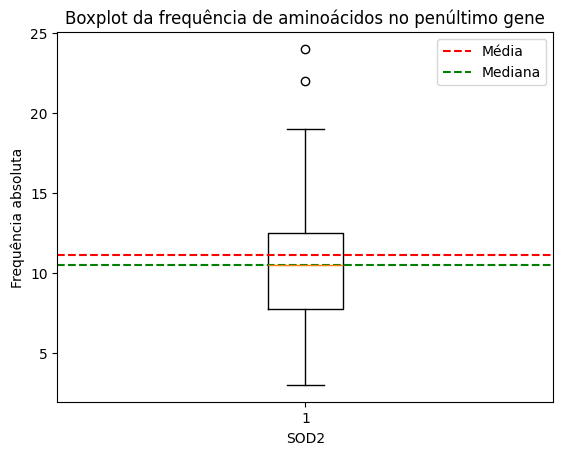

In [46]:
import matplotlib.pyplot as plt

penultimo_gene = aminoacidos.iloc[:, -2]

plt.boxplot(penultimo_gene)

plt.axhline(penultimo_gene.mean(), color="red", linestyle="--", label="Média")
plt.axhline(penultimo_gene.median(), color="green", linestyle="--", label="Mediana")

plt.title("Boxplot da frequência de aminoácidos no penúltimo gene")
plt.ylabel("Frequência absoluta")
plt.xlabel(penultimo_gene.name)
plt.legend()
plt.show()

## 05 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a variância amostral não viciada. Qual o valor da variância da Prolina? E do terceiro gene?

In [47]:
def variancia_amostral(objeto):
    nome = objeto.name
    valor = objeto.var(ddof=1)
    return f"A variância amostral de {nome} é {round(valor, 2)}"

In [48]:
variancia_amostral(aminoacidos.loc["Prolina"])

'A variância amostral de Prolina é 1308.7'

In [49]:
variancia_amostral(aminoacidos.iloc[:, 2])

'A variância amostral de HLA-A é 89.67'

## 06 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o desvio padrão. Qual o valor d o desvio padrão do Triptofano? E do gene de index -1?

In [50]:
def desvio_padrao(objeto):
    nome = objeto.name
    valor = objeto.std(ddof=1)
    return f"O desvio padrão de {nome} é {round(valor, 2)}"

In [51]:
desvio_padrao(aminoacidos.loc["Triptofano"])

'O desvio padrão de Triptofano é 3.21'

In [52]:
desvio_padrao(aminoacidos.iloc[:, -1])

'O desvio padrão de APOE é 13.85'

## 07 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o coeficiente de variação. Qual o valor do coeficiente de variação da Leucina? E do gene de index 1?

In [53]:
def coeficiente_variacao(objeto):
    nome = objeto.name
    valor = (objeto.std(ddof=1) / objeto.mean()) * 100
    return f"O coeficiente de variação de {nome} é {round(valor, 2)}%"

In [54]:
coeficiente_variacao(aminoacidos.loc["Leucina"])

'O coeficiente de variação de Leucina é 99.33%'

In [55]:
coeficiente_variacao(aminoacidos.iloc[:, 1])

'O coeficiente de variação de TP53 é 54.14%'

## 08 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas resumo.
Obs.: Use um dicionário onde os index são os nomes e os valores as medidas.

In [60]:
def medidas_resumo(objeto):
    return {
        "Nome": objeto.name,
        "Média": round(objeto.mean(), 2),
        "Mediana": round(objeto.median(), 2),
        "Moda": objeto.mode().tolist(),
        "Amplitude": objeto.max() - objeto.min(),
        "Variância": round(objeto.var(ddof=1), 2),
        "Desvio padrão": round(objeto.std(ddof=1), 2),
        "Coeficiente de variação (%)": round((objeto.std(ddof=1) / objeto.mean()) * 100, 2),
        "Q1": round(objeto.quantile(0.25), 2),
        "Q2": round(objeto.quantile(0.50), 2),
        "Q3": round(objeto.quantile(0.75), 2),
        "Intervalo interquartil": round(objeto.quantile(0.75) - objeto.quantile(0.25), 2)
    }

In [57]:
medidas_resumo(aminoacidos.loc["Arginina"])

{'Nome': 'Arginina',
 'Média': np.float64(34.6),
 'Mediana': np.float64(28.0),
 'Moda': [7, 26, 28, 36, 76],
 'Amplitude': np.int64(69),
 'Variância': np.float64(648.8),
 'Desvio padrão': np.float64(25.47),
 'Coeficiente de variação (%)': np.float64(73.62),
 'Q1': np.float64(26.0),
 'Q2': np.float64(28.0),
 'Q3': np.float64(36.0),
 'Intervalo interquartil': np.float64(10.0)}

## 09 – Defina uma função que retorne qual o gene com o maior CV de frequência de aminoácidos. Obtenha os boxplot dos genes. Os dados concordam? Porque?

In [61]:
def gene_maior_cv(df):

    cvs = {}

    for gene in df.columns:
        cv = (df[gene].std(ddof=1) / df[gene].mean()) * 100
        cvs[gene] = cv

    maior_gene = max(cvs, key=cvs.get)

    return f"O gene com maior CV é {maior_gene} ({round(cvs[maior_gene],2)}%)"

In [63]:
gene_maior_cv(aminoacidos)

'O gene com maior CV é APOE (80.78%)'

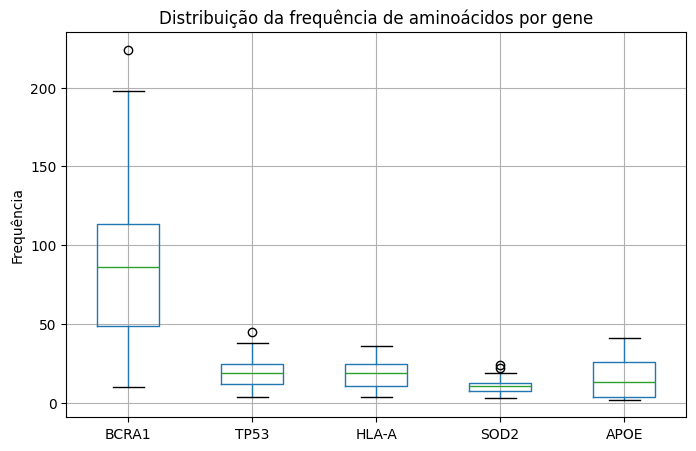

In [65]:
plt.figure(figsize=(8,5))

aminoacidos.boxplot()

plt.title("Distribuição da frequência de aminoácidos por gene")
plt.ylabel("Frequência")

plt.show()

R: A principio não pois no gráfico o gene com a frequencia mais bem distribuida não é o APOE e sim o BCRA1, mas isso se dá por ele ser um gene muito maior do que o APOE, no calculo de média de genes o BCRA1 é o maior gene e o APOE é o menor, mas avaliando o dataframe também é o gene com a dispersão dos aa mais bem distribuidos o que se comprova também no calculo de CV.

## 10 – Defina uma função que retorne qual o aminoácidos com o maior CV dentre os genes. Obtenha os boxplot dos aminoácidos. Os dados concordam? Porque?

In [66]:
def aa_maior_cv(df):

    cvs = {}

    for aa in df.index:
        cv = (df.loc[aa].std(ddof=1) / df.loc[aa].mean()) * 100
        cvs[aa] = cv

    maior_aa = max(cvs, key=cvs.get)

    return f"O aminoácido com maior CV é {maior_aa} ({round(cvs[maior_aa],2)}%)"

In [67]:
aa_maior_cv(aminoacidos)

'O aminoácido com maior CV é Asparagina (163.28%)'

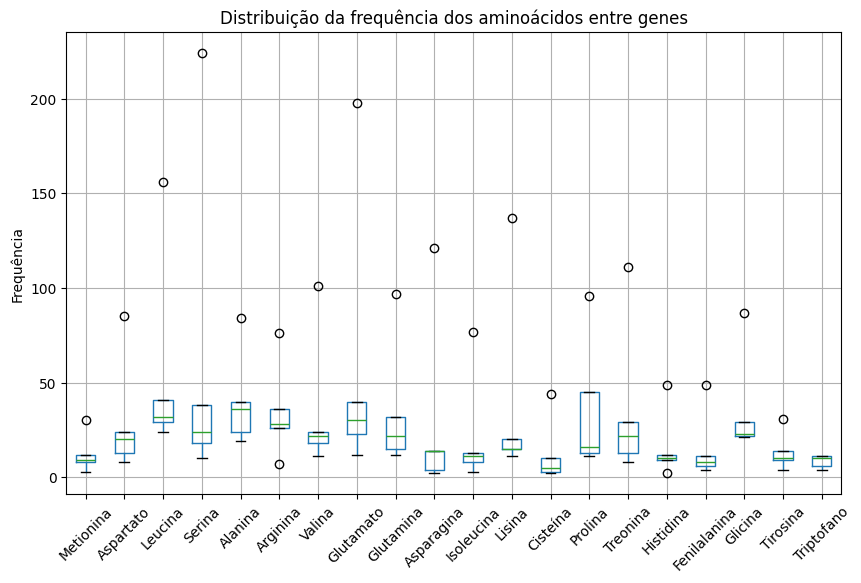

In [68]:
plt.figure(figsize=(10,6))

aminoacidos.T.boxplot()

plt.title("Distribuição da frequência dos aminoácidos entre genes")
plt.ylabel("Frequência")

plt.xticks(rotation=45)

plt.show()

Não, pois o aminoácido com maior coeficiente de variação não apresenta maior dispersão entre os genes, o que pode ser observado no boxplot pela maior variação entre outros genes como o glutamato.Então não necessariamente, o coeficiente de variação mede a dispersão relativa em relação à média, enquanto o boxplot representa a dispersão absoluta dos dados. Assim, um aminoácido pode apresentar maior variabilidade proporcional (maior CV) sem apresentar a maior dispersão visual no boxplot